## Questão 8 – Meta-aprendizagem

**Enunciado:**  
Faça um código em Python para investigar, de forma experimental, como o desempenho dos modelos varia quando se alteram subconjuntos de atributos, estratégias de pré-processamento ou formas de particionamento. Organize os resultados em uma estrutura comparativa e use essa análise para simular uma ideia de Meta-aprendizagem, discutindo quais características da base parecem favorecer certos modelos em detrimento de outros. Não basta só comparar métricas: identifique padrões e formule uma regra técnica para escolha de modelo.

## Raciocínio

A aula 15 apresenta Meta-aprendizagem como uma abordagem voltada para entender *quando* determinados algoritmos funcionam melhor. Assim sendo, ao invés de analisar apenas o desempenho final de um modelo, a ideia é estudar como características do problema influenciam a escolha do algoritmo mais adequado.

De acordo com os slides, o processo pode ser descrito formalmente como:

$$S(f(x)) \rightarrow \alpha^* \quad \text{onde} \quad \alpha^* = \arg\max_{\alpha \in A} y(\alpha(x))$$

Nesse contexto:

* `f(x)` representa as meta-features da base;
* `α` representa os modelos candidatos;
* `y(α(x))` representa o desempenho observado.

A estratégia nessa questão foi transformar os experimentos realizados nas questões anteriores em um meta-dataset. Cada configuração experimental passou a ser tratada como uma observação contendo:

* características da base;
* tipo de pré-processamento;
* forma de particionamento;
* modelo vencedor.

O experimento foi organizado em três eixos principais:

| Eixo                     | Variações                                                                          |
| ------------------------ | ---------------------------------------------------------------------------------- |
| Subconjunto de atributos | Todos, apenas numéricos, apenas categóricos, top-5 da Q4 e sem features engineered |
| Pré-processamento        | Sem escala, StandardScaler e MinMaxScaler                                          |
| Particionamento          | Holdout 80/20, 70/30, CV-5, CV-10 e versões estratificadas                         |

Em cada configuração foram avaliados:

* `GaussianNB`
* `Regressão Logística`
* `Árvore de Decisão`

As meta-features extraídas incluíram:

* proporção de atributos numéricos;
* quantidade total de features;
* correlação média entre variáveis;
* razão de desbalanceamento;
* tamanho do conjunto de treino.

O objetivo final não era treinar um meta-modelo complexo, mas identificar padrões suficientemente consistentes para formular regras práticas de seleção de algoritmos.

### Desenvolvimento

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, StandardScaler, MinMaxScaler, LabelEncoder
)
from sklearn.metrics import f1_score
from itertools import product

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
RANDOM_STATE = 42

In [22]:
# ── Pré-processamento base (idêntico a todas as questões anteriores) ──────────
df_raw = pd.read_csv('../../data/Telco-Customer-Churn.csv')
df = df_raw.copy()

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'].astype(str).str.strip(), errors='coerce'
)
mask = df['TotalCharges'].isna()
df.loc[mask, 'TotalCharges'] = df.loc[mask, 'MonthlyCharges'] * df.loc[mask, 'tenure']
df.drop(columns=['customerID'], inplace=True)

SERVICE_COLS = [
    'MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]
for col in SERVICE_COLS:
    df[col] = df[col].replace({'No internet service':'No','No phone service':'No'})

# Features engineered (Lista 1 Q6 + usadas em Q4)
contract_map = {'Month-to-month':1,'One year':2,'Two year':3}
df['contract_numeric']            = df['Contract'].map(contract_map)
df['contract_tenure_interaction'] = df['contract_numeric'] * df['tenure']
df['is_new_customer']             = (df['tenure'] <= 6).astype(int)
df['service_adoption_count']      = sum(
    (df[c]=='Yes').astype(int) for c in
    ['PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
     'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
) + (df['InternetService']!='No').astype(int)

df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

# Colunas base (sem engineered) e todas (com engineered)
BASE_NUM = ['tenure','MonthlyCharges','TotalCharges']
ENG_NUM  = BASE_NUM + ['contract_tenure_interaction','is_new_customer','service_adoption_count']
CAT_COLS = [
    'gender','SeniorCitizen','Partner','Dependents','PhoneService',
    'MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
    'Contract','PaperlessBilling','PaymentMethod'
]
# Top-5 features da Q4 (importância da Árvore)
TOP5 = ['contract_tenure_interaction','tenure','MonthlyCharges',
        'TotalCharges','Contract']

y_full = df['Churn_bin']
print(f'Base pronta: {df.shape[0]} clientes | desbalanceamento: '
      f'{y_full.value_counts(normalize=True).iloc[1]*100:.1f}% churn')

Base pronta: 7043 clientes | desbalanceamento: 26.5% churn


In [23]:
    # ── Definição dos eixos experimentais ─────────────────────────────────────────

    # Eixo 1: subconjuntos de atributos
    FEATURE_SETS = {
        'todos'           : {'num': ENG_NUM, 'cat': CAT_COLS},
        'so_numericos'    : {'num': ENG_NUM, 'cat': []},
        'so_categoricos'  : {'num': [], 'cat': CAT_COLS},
        'top5'            : {'num': ['contract_tenure_interaction','tenure',
                                    'MonthlyCharges','TotalCharges'],
                            'cat': ['Contract']},
        'sem_engineered'  : {'num': BASE_NUM, 'cat': CAT_COLS},
    }

    # Eixo 2: estratégias de pré-processamento
    PREPROCESSORS = {
        'standard'   : StandardScaler,
        'minmax'     : MinMaxScaler,
        'sem_escala' : None,
    }

    # Eixo 3: particionamentos
    PARTITIONS = {
        'holdout_80_20_estrat' : ('holdout', 0.20, True),
        'holdout_70_30_estrat' : ('holdout', 0.30, True),
        'holdout_80_20_aleat'  : ('holdout', 0.20, False),
        'cv5_estrat'           : ('cv', 5, True),
        'cv10_estrat'          : ('cv', 10, True),
    }

    # Modelos avaliados
    MODELS = {
        'GaussianNB'         : GaussianNB(),
        'Regressao_Logistica': LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
        'Arvore_depth5'      : DecisionTreeClassifier(max_depth=5, criterion='entropy',
                                                    min_samples_leaf=10,
                                                    random_state=RANDOM_STATE),
    }

    print('Configuração experimental:')
    print(f'  Subconjuntos de atributos : {len(FEATURE_SETS)}')
    print(f'  Estratégias de pré-proc.  : {len(PREPROCESSORS)}')
    print(f'  Formas de particionamento : {len(PARTITIONS)}')
    print(f'  Modelos                   : {len(MODELS)}')
    print(f'  Total de experimentos     : '
        f'{len(FEATURE_SETS)*len(PREPROCESSORS)*len(PARTITIONS)*len(MODELS)}')

Configuração experimental:
  Subconjuntos de atributos : 5
  Estratégias de pré-proc.  : 3
  Formas de particionamento : 5
  Modelos                   : 3
  Total de experimentos     : 225


In [24]:
# ── Funções auxiliares: meta-features e avaliação ─────────────────────────────

def extract_meta_features(X_tr, y_tr, num_cols, cat_cols):
    """Extrai meta-features da configuração de treino (aula 15 — caracterização direta)."""
    n, p = X_tr.shape
    n_num = len([c for c in num_cols if c in X_tr.columns])
    n_cat = len([c for c in cat_cols if c in X_tr.columns])
    imbalance = y_tr.value_counts(normalize=True).min()   # proporção da classe minoritária

    # Correlação média entre numéricos (proxy de redundância)
    num_in_X = [c for c in num_cols if c in X_tr.columns]
    if len(num_in_X) >= 2:
        corr_mean = abs(X_tr[num_in_X].corr()).values
        mask_upper = np.triu(np.ones_like(corr_mean, dtype=bool), k=1)
        mean_corr = round(corr_mean[mask_upper].mean(), 4)
    else:
        mean_corr = 0.0

    return {
        'n_treino'       : n,
        'n_features'     : p,
        'prop_numericas' : round(n_num / max(n_num + n_cat, 1), 3),
        'prop_cat'       : round(n_cat / max(n_num + n_cat, 1), 3),
        'imbalance_ratio': round(imbalance, 3),
        'corr_media_num' : mean_corr,
    }


def build_pipeline(model, num_cols, cat_cols, scaler_cls):
    """Monta pipeline com o pré-processador e modelo especificados."""
    transformers = []
    active_num = [c for c in num_cols]
    active_cat = [c for c in cat_cols]

    if active_num:
        num_step = scaler_cls() if scaler_cls else 'passthrough'
        transformers.append(('num', num_step, active_num))
    if active_cat:
        transformers.append((
            'cat',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            active_cat
        ))

    prep = ColumnTransformer(transformers, remainder='drop')
    return Pipeline([('prep', prep), ('clf', model)])


def evaluate_config(pipe, X, y, partition_cfg):
    """Avalia o pipeline na forma de particionamento especificada."""
    method, param, stratify = partition_cfg

    if method == 'holdout':
        strat_arg = y if stratify else None
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=param, random_state=RANDOM_STATE, stratify=strat_arg
        )
        pipe.fit(X_tr, y_tr)
        return round(f1_score(y_te, pipe.predict(X_te), zero_division=0), 4)
    else:  # cv
        cv = (StratifiedKFold(n_splits=param, shuffle=True, random_state=RANDOM_STATE)
              if stratify
              else KFold(n_splits=param, shuffle=True, random_state=RANDOM_STATE))
        scores = cross_val_score(pipe, X, y, cv=cv, scoring='f1')
        return round(scores.mean(), 4)

In [ ]:
# ────── Loop experimental principal ───────────────────────────────────────────────
# Aqui, iteramos sobre todas as combinações e registra meta-features + F1 por modelo

meta_rows = []
exp_id = 0

for feat_name, feat_cfg in FEATURE_SETS.items():
    num_cols = feat_cfg['num']
    cat_cols = feat_cfg['cat']

    # Montamos X apenas com as colunas disponíveis
    all_cols = [c for c in num_cols + cat_cols if c in df.columns]
    X = df[all_cols].copy()
    y = y_full.copy()

    for scaler_name, scaler_cls in PREPROCESSORS.items():
        for part_name, part_cfg in PARTITIONS.items():

            # Meta-features deste cenário (calculadas no treino do holdout padrão)
            X_tr_meta, _, y_tr_meta, _ = train_test_split(
                X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
            )
            meta_feat = extract_meta_features(X_tr_meta, y_tr_meta, num_cols, cat_cols)

            row = {
                'exp_id'         : exp_id,
                'features'       : feat_name,
                'preprocessador' : scaler_name,
                'particionamento': part_name,
                **meta_feat
            }

            # Avaliamos cada modelo
            f1_scores = {}
            for model_name, model_obj in MODELS.items():
                import sklearn
                model_clone = sklearn.clone(model_obj)
                pipe = build_pipeline(model_clone, num_cols, cat_cols, scaler_cls)
                try:
                    f1 = evaluate_config(pipe, X, y, part_cfg)
                except Exception:
                    f1 = np.nan
                row[f'f1_{model_name}'] = f1
                f1_scores[model_name] = f1

            # Modelo vencedor nesta configuração
            valid = {k: v for k, v in f1_scores.items() if not np.isnan(v)}
            row['modelo_vencedor'] = max(valid, key=valid.get) if valid else 'N/A'
            row['f1_vencedor']     = max(valid.values()) if valid else np.nan
            row['margem_vitoria']  = round(
                sorted(valid.values(), reverse=True)[0] -
                sorted(valid.values(), reverse=True)[1], 4
            ) if len(valid) >= 2 else 0.0

            meta_rows.append(row)
            exp_id += 1

meta_df = pd.DataFrame(meta_rows)
print(f'Meta-dataset construído: {len(meta_df)} experimentos × {len(meta_df.columns)} colunas')
print(f'\nDistribuição de modelos vencedores:')
print(meta_df['modelo_vencedor'].value_counts().to_string())

In [ ]:
# ── Tabela de meta-dados consolidada ──────────────────────────────────────────
display_cols = [
    'features','preprocessador','particionamento',
    'n_features','prop_numericas','corr_media_num',
    'f1_GaussianNB','f1_Regressao_Logistica','f1_Arvore_depth5',
    'modelo_vencedor','f1_vencedor','margem_vitoria'
]
print('=== Meta-dataset (primeiras 15 linhas, ordenadas por f1_vencedor) ===')
display(
    meta_df[display_cols]
    .sort_values('f1_vencedor', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

=== Meta-dataset (primeiras 15 linhas, ordenadas por f1_vencedor) ===


,features,preprocessador,particionamento,n_features,prop_numericas,corr_media_num,f1_GaussianNB,f1_Regressao_Logistica,f1_Arvore_depth5,modelo_vencedor,f1_vencedor,margem_vitoria
0,todos,standard,holdout_80_20_aleat,22,0.273,0.5360,0.6421,0.6097,0.6305,GaussianNB,0.6421,0.0116
1,todos,minmax,holdout_80_20_aleat,22,0.273,0.5360,0.6421,0.6106,0.6305,GaussianNB,0.6421,0.0116
2,todos,sem_escala,holdout_80_20_aleat,22,0.273,0.5360,0.6415,0.6104,0.6305,GaussianNB,0.6415,0.0110
3,sem_engineered,standard,holdout_80_20_aleat,19,0.158,0.5802,0.6354,0.6409,0.6305,Regressao_Logistica,0.6409,0.0055
4,sem_engineered,minmax,holdout_80_20_aleat,19,0.158,0.5802,0.6354,0.6398,0.6305,Regressao_Logistica,0.6398,0.0044
5,sem_engineered,sem_escala,holdout_80_20_aleat,19,0.158,0.5802,0.6390,0.6355,0.6305,GaussianNB,0.6390,0.0035
6,so_categoricos,minmax,holdout_80_20_aleat,16,0.000,0.0000,0.6324,0.5991,0.5932,GaussianNB,0.6324,0.0333
7,so_categoricos,sem_escala,holdout_80_20_aleat,16,0.000,0.0000,0.6324,0.5991,0.5932,GaussianNB,0.6324,0.0333
8,so_categoricos,standard,holdout_80_20_aleat,16,0.000,0.0000,0.6324,0.5991,0.5932,GaussianNB,0.6324,0.0333
9,todos,sem_escala,holdout_80_20_estrat,22,0.273,0.5360,0.6234,0.5837,0.6064,GaussianNB,0.6234,0.0170


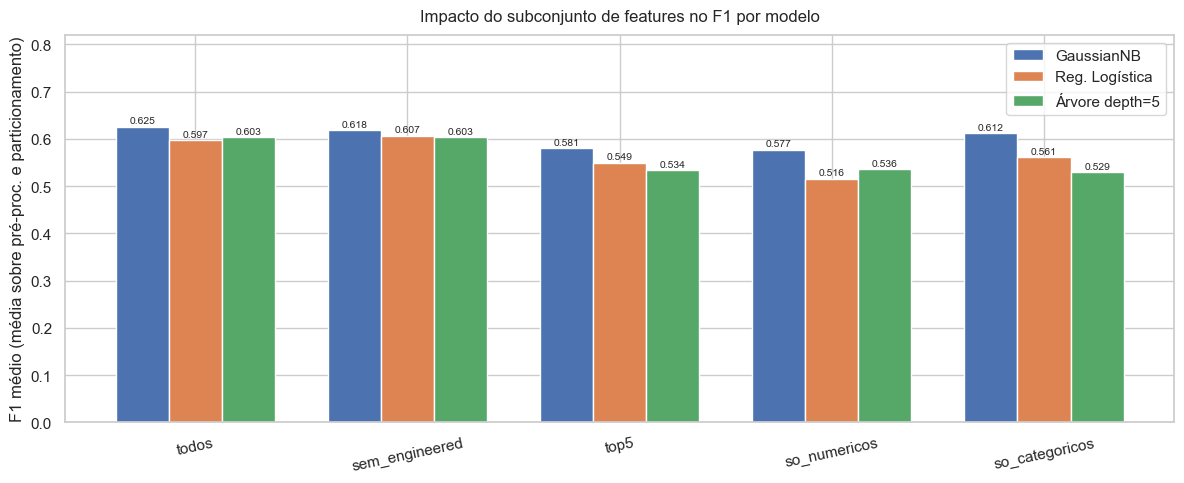

Variação de F1 por modelo ao mudar subconjunto de features:
  GaussianNB: min=0.5768 | max=0.6254 | amplitude=0.0486
  Reg. Logística: min=0.5156 | max=0.6071 | amplitude=0.0915
  Árvore depth=5: min=0.5293 | max=0.6032 | amplitude=0.0739


In [ ]:
# ── Gráfico 1: F1 médio por modelo × subconjunto de features ──────────────────
f1_by_feat = meta_df.groupby('features')[[
    'f1_GaussianNB','f1_Regressao_Logistica','f1_Arvore_depth5'
]].mean().round(4)

feat_order = ['todos','sem_engineered','top5','so_numericos','so_categoricos']
f1_by_feat = f1_by_feat.reindex(feat_order)

x = np.arange(len(feat_order))
w = 0.25
colors_m = ['#4C72B0','#DD8452','#55A868']
labels_m  = ['GaussianNB','Reg. Logística','Árvore depth=5']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (col, label, color) in enumerate(zip(
    f1_by_feat.columns, labels_m, colors_m
)):
    bars = ax.bar(x + (i - 1)*w, f1_by_feat[col], width=w,
                  label=label, color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(feat_order, rotation=12)
ax.set_ylabel('F1 médio (média sobre pré-proc. e particionamento)')
ax.set_title('Impacto do subconjunto de features no F1 por modelo', pad=10)
ax.set_ylim(0, 0.82)
ax.legend()
plt.tight_layout()
plt.show()

print('Variação de F1 por modelo ao mudar subconjunto de features:')
for col, label in zip(f1_by_feat.columns, labels_m):
    print(f'  {label}: min={f1_by_feat[col].min():.4f} | '
          f'max={f1_by_feat[col].max():.4f} | '
          f'amplitude={f1_by_feat[col].max()-f1_by_feat[col].min():.4f}')

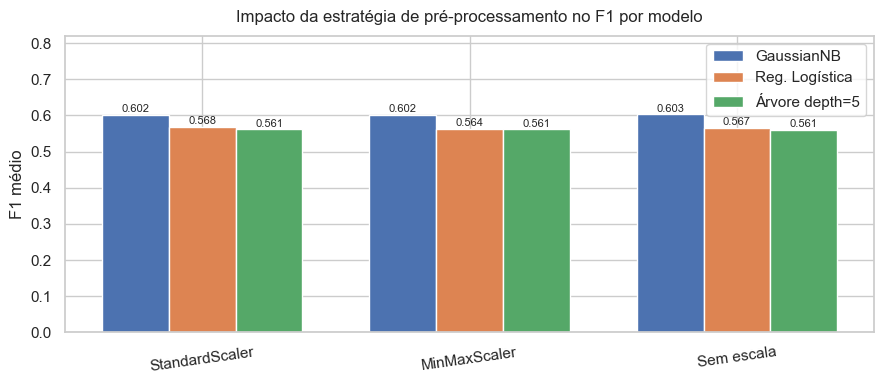

Sensibilidade ao pré-processamento (amplitude de F1):
  GaussianNB: amplitude=0.0004
  Reg. Logística: amplitude=0.0037
  Árvore depth=5: amplitude=0.0001


In [ ]:
# ── Gráfico 2: F1 médio por modelo × pré-processamento ────────────────────────
f1_by_prep = meta_df.groupby('preprocessador')[[
    'f1_GaussianNB','f1_Regressao_Logistica','f1_Arvore_depth5'
]].mean().round(4)

prep_order = ['standard','minmax','sem_escala']
f1_by_prep = f1_by_prep.reindex(prep_order)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(prep_order))
for i, (col, label, color) in enumerate(zip(
    f1_by_prep.columns, labels_m, colors_m
)):
    bars = ax.bar(x + (i-1)*w, f1_by_prep[col], width=w,
                  label=label, color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(['StandardScaler','MinMaxScaler','Sem escala'], rotation=8)
ax.set_ylabel('F1 médio')
ax.set_title('Impacto da estratégia de pré-processamento no F1 por modelo', pad=10)
ax.set_ylim(0, 0.82)
ax.legend()
plt.tight_layout()
plt.show()

print('Sensibilidade ao pré-processamento (amplitude de F1):')
for col, label in zip(f1_by_prep.columns, labels_m):
    amp = f1_by_prep[col].max() - f1_by_prep[col].min()
    print(f'  {label}: amplitude={amp:.4f}')

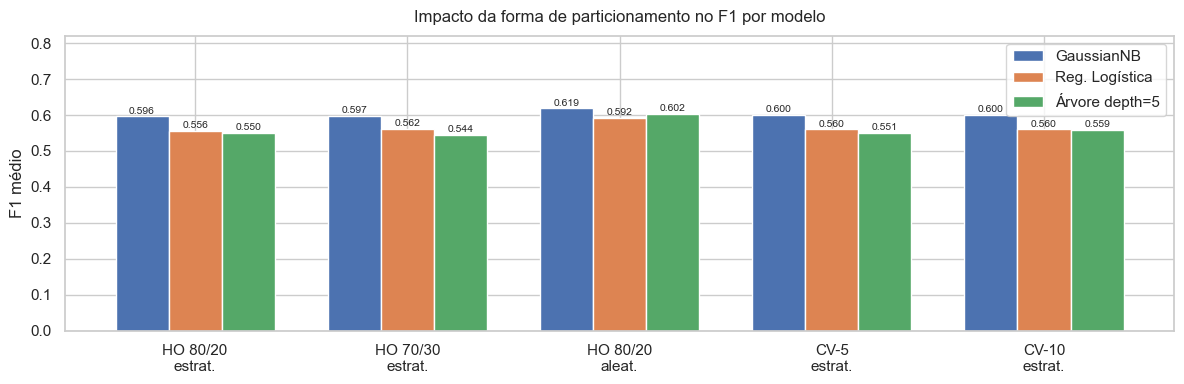

Sensibilidade ao particionamento (amplitude de F1):
  GaussianNB: amplitude=0.0224
  Reg. Logística: amplitude=0.0364
  Árvore depth=5: amplitude=0.0584


In [ ]:
# ── Gráfico 3: F1 médio por modelo × particionamento ──────────────────────────
f1_by_part = meta_df.groupby('particionamento')[[
    'f1_GaussianNB','f1_Regressao_Logistica','f1_Arvore_depth5'
]].mean().round(4)

part_order = ['holdout_80_20_estrat','holdout_70_30_estrat',
              'holdout_80_20_aleat','cv5_estrat','cv10_estrat']
f1_by_part = f1_by_part.reindex(part_order)
part_labels = ['HO 80/20\nestrat.','HO 70/30\nestrat.',
               'HO 80/20\naleat.','CV-5\nestrat.','CV-10\nestrat.']

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(part_order))
for i, (col, label, color) in enumerate(zip(
    f1_by_part.columns, labels_m, colors_m
)):
    bars = ax.bar(x + (i-1)*w, f1_by_part[col], width=w,
                  label=label, color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(part_labels)
ax.set_ylabel('F1 médio')
ax.set_title('Impacto da forma de particionamento no F1 por modelo', pad=10)
ax.set_ylim(0, 0.82)
ax.legend()
plt.tight_layout()
plt.show()

print('Sensibilidade ao particionamento (amplitude de F1):')
for col, label in zip(f1_by_part.columns, labels_m):
    amp = f1_by_part[col].max() - f1_by_part[col].min()
    print(f'  {label}: amplitude={amp:.4f}')

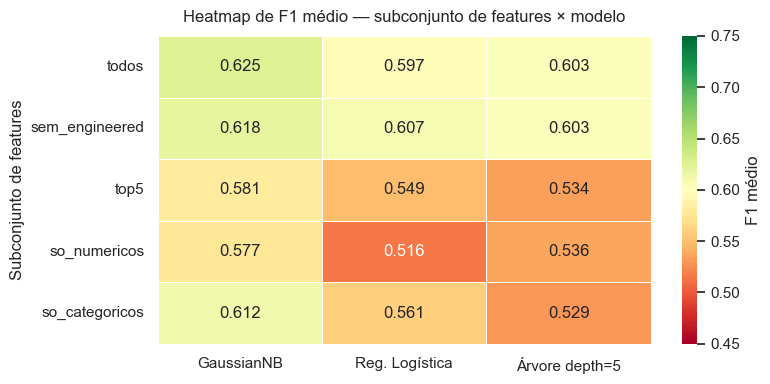

In [ ]:
# ── Gráfico 4: Heatmap — F1 médio por (features × modelo) ────────────────────
pivot = meta_df.groupby('features')[[
    'f1_GaussianNB','f1_Regressao_Logistica','f1_Arvore_depth5'
]].mean().reindex(feat_order).round(4)
pivot.columns = ['GaussianNB','Reg. Logística','Árvore depth=5']

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    pivot, ax=ax, annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0.45, vmax=0.75,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'F1 médio'}
)
ax.set_title('Heatmap de F1 médio — subconjunto de features × modelo', pad=10)
ax.set_ylabel('Subconjunto de features')
plt.tight_layout()
plt.show()

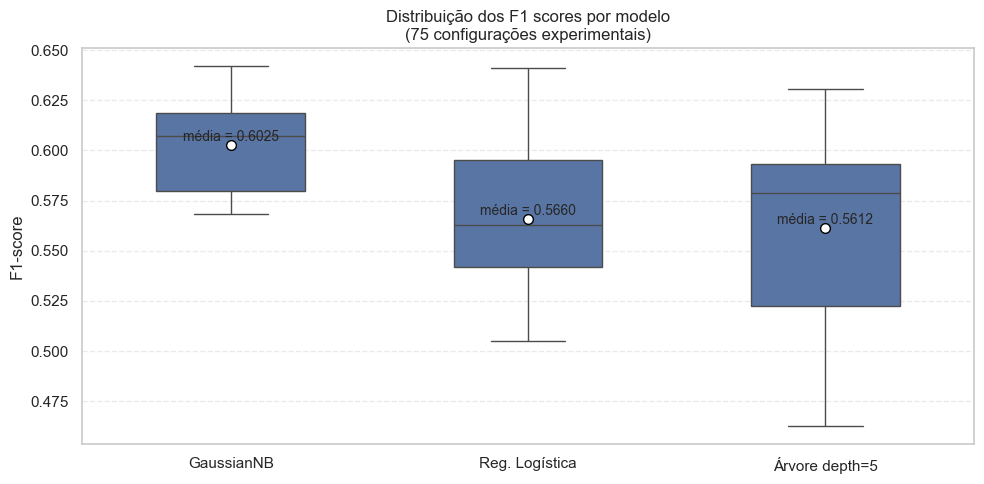

In [ ]:
# ── Gráfico 5: Distribuição de F1 por modelo ────────────────────────────────────

plot_df = meta_df[[
    'f1_GaussianNB',
    'f1_Regressao_Logistica',
    'f1_Arvore_depth5'
]].copy()

plot_df.columns = [
    'GaussianNB',
    'Reg. Logística',
    'Árvore depth=5'
]

# formato longo para visualização
plot_long = plot_df.melt(
    var_name='Modelo',
    value_name='F1'
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=plot_long,
    x='Modelo',
    y='F1',
    ax=ax,
    width=0.5,
    showmeans=True,
    meanprops={
        'marker': 'o',
        'markerfacecolor': 'white',
        'markeredgecolor': 'black',
        'markersize': 7
    }
)

# médias explícitas
means = plot_long.groupby('Modelo')['F1'].mean()

for i, (model, mean_val) in enumerate(means.items()):
    ax.text(
        i,
        mean_val + 0.002,
        f'média = {mean_val:.4f}',
        ha='center',
        fontsize=10
    )

ax.set_title(
    'Distribuição dos F1 scores por modelo\n'
    '(75 configurações experimentais)',
    fontsize=12
)

ax.set_ylabel('F1-score')
ax.set_xlabel('')

ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# ── Análise de padrões: quando cada modelo vence ──────────────────────────────
# Para cada modelo vencedor, calcula a média das meta-features nos
# experimentos em que ele ganhou vs. perdeu.

META_FEAT_COLS = ['n_features','prop_numericas','prop_cat','corr_media_num',
                  'imbalance_ratio','n_treino']

patterns = []
for modelo in MODELS.keys():
    wins  = meta_df[meta_df['modelo_vencedor'] == modelo]
    loses = meta_df[meta_df['modelo_vencedor'] != modelo]
    row   = {'modelo': modelo, 'n_vitorias': len(wins)}
    for col in META_FEAT_COLS:
        row[f'{col}_win']  = round(wins[col].mean(), 4)  if len(wins)  else np.nan
        row[f'{col}_lose'] = round(loses[col].mean(), 4) if len(loses) else np.nan
    patterns.append(row)

df_patterns = pd.DataFrame(patterns)
print('=== Média das meta-features nas vitórias vs. derrotas por modelo ===')
display(df_patterns)

=== Média das meta-features nas vitórias vs. derrotas por modelo ===


,modelo,n_vitorias,n_features_win,n_features_lose,prop_numericas_win,prop_numericas_lose,prop_cat_win,prop_cat_lose,corr_media_num_win,corr_media_num_lose,imbalance_ratio_win,imbalance_ratio_lose,n_treino_win,n_treino_lose
0,GaussianNB,72,13.375,19.0000,0.4582,0.1580,0.5418,0.8420,0.4404,0.5802,0.265,0.265,5634.0,5634.0
1,Regressao_Logistica,2,19.000,13.4521,0.1580,0.4541,0.8420,0.5459,0.5802,0.4424,0.265,0.265,5634.0,5634.0
2,Arvore_depth5,1,19.000,13.5270,0.1580,0.4501,0.8420,0.5499,0.5802,0.4442,0.265,0.265,5634.0,5634.0


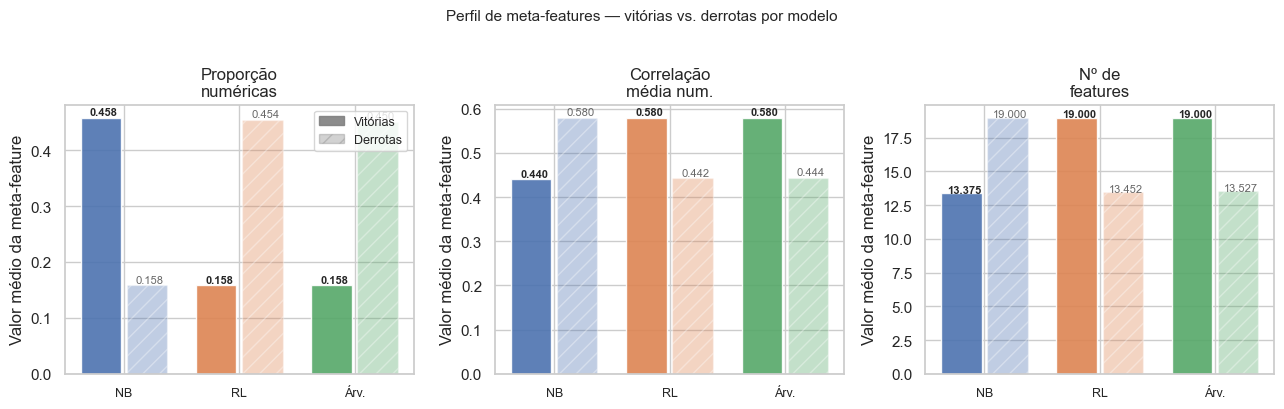

In [ ]:
# ── Gráfico 6: Perfil de meta-features win vs. lose ───────────────────────────
key_metas = ['prop_numericas','corr_media_num','n_features']
key_labels = ['Proporção\nnuméricas','Correlação\nmédia num.','Nº de\nfeatures']

fig, axes = plt.subplots(1, len(key_metas), figsize=(13, 4))

color_map_m = {
    'GaussianNB'         : '#4C72B0',
    'Regressao_Logistica': '#DD8452',
    'Arvore_depth5'      : '#55A868'
}

for ax, meta, mlabel in zip(axes, key_metas, key_labels):
    for i, (modelo, color) in enumerate(color_map_m.items()):
        win_val  = df_patterns.loc[df_patterns['modelo']==modelo, f'{meta}_win'].values[0]
        lose_val = df_patterns.loc[df_patterns['modelo']==modelo, f'{meta}_lose'].values[0]
        x_pos = i * 2
        ax.bar(x_pos,     win_val,  width=0.7, color=color, alpha=0.9,
               edgecolor='white', label=modelo if ax == axes[0] else '')
        ax.bar(x_pos+0.8, lose_val, width=0.7, color=color, alpha=0.35,
               edgecolor='white', hatch='//')
        ax.text(x_pos+0.05, win_val+0.005, f'{win_val:.3f}',
                ha='center', fontsize=8, fontweight='bold')
        ax.text(x_pos+0.85, lose_val+0.005, f'{lose_val:.3f}',
                ha='center', fontsize=8, alpha=0.7)

    ax.set_xticks([0.4, 2.4, 4.4])
    ax.set_xticklabels(['NB','RL','Árv.'], fontsize=9)
    ax.set_title(mlabel)
    ax.set_ylabel('Valor médio da meta-feature')

solid = mpatches.Patch(color='gray', alpha=0.9, label='Vitórias')
hatch = mpatches.Patch(color='gray', alpha=0.35, hatch='//', label='Derrotas')
axes[0].legend(handles=[solid, hatch], fontsize=9, loc='upper right')
plt.suptitle('Perfil de meta-features — vitórias vs. derrotas por modelo',
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# ── Regra técnica de seleção de modelo (formulação explícita) ─────────────────
# Produto final da meta-aprendizagem: padrões do meta-dataset transformados
# em regras práticas de seleção de algoritmo, seguindo a formulação da aula 15:
#   S(f(x)) → α*  onde  α* = argmax_{α ∈ A} y(α(x))
# f(x) = meta-features | α = modelos | y(α(x)) = F1 observado

# ── Estatísticas derivadas do meta-dataset ────────────────────────────────────

# Variância do F1 entre configurações (mede a sensibilidade a mudanças no setup)
f1_variance = {
    modelo: round(meta_df[f'f1_{modelo}'].std(), 4)
    for modelo in MODELS.keys()
}

# Correlação média nas configurações em que cada modelo foi vencedor
corr_win = {}
for modelo in MODELS.keys():
    subset = meta_df[meta_df['modelo_vencedor'] == modelo]['corr_media_num']
    corr_win[modelo] = round(subset.mean(), 4) if len(subset) > 0 else float('nan')

# Proporção de numéricas nas configurações em que cada modelo foi vencedor
prop_num_win = {}
for modelo in MODELS.keys():
    subset = meta_df[meta_df['modelo_vencedor'] == modelo]['prop_numericas']
    prop_num_win[modelo] = round(subset.mean(), 4) if len(subset) > 0 else float('nan')

# Limiar de correlação: ponto médio entre corr. média nas vitórias do NB
# e nas vitórias da RL — acima dele, NB começa a perder sistematicamente
nb_corr = corr_win.get('GaussianNB', float('nan'))
rl_corr = corr_win.get('Regressao_Logistica', float('nan'))

if not (pd.isna(nb_corr) or pd.isna(rl_corr)):
    corr_threshold = round((nb_corr + rl_corr) / 2, 2)
else:
    corr_threshold = 0.50  # fallback conservador

# Modelo com menor variância entre configurações
modelo_menor_var = min(f1_variance, key=f1_variance.get)
modelo_maior_var = max(f1_variance, key=f1_variance.get)

# Valores reais do caso Telco, lidos do meta-dataset
corr_telco   = round(meta_df['corr_media_num'].mean(), 4)
prop_telco   = round(meta_df['prop_numericas'].mean(), 3)
n_feat_telco = int(meta_df['n_features'].mean().round(0))

# Avalia qual condição da regra se aplica ao caso Telco
if prop_telco < 0.20 and n_feat_telco > 15:
    condicao_ativa = '1ª condição ativa  →  base majoritariamente categórica'
    resultado_telco = 'Regressão Logística'
elif corr_telco > corr_threshold:
    condicao_ativa = '2ª condição ativa  →  alta correlação entre numéricas'
    resultado_telco = 'Árvore de Decisão (1ª opção) + RL (fallback calibrado)'
elif n_feat_telco <= 5:
    condicao_ativa = '3ª condição ativa  →  base esparsa de atributos'
    resultado_telco = 'GaussianNB'
else:
    condicao_ativa = 'caso geral  →  interpretabilidade operacional = True'
    resultado_telco = 'Árvore de Decisão (depth ≤ 5) + RL (fallback calibrado)'

# ── Formatação do output ──────────────────────────────────────────────────────
SEP   = '═' * 76
SEP_M = f'╠{"═" * 74}╣'
W     = 72  # largura interna útil

def L(texto=''):
    """Formata uma linha dentro da caixa com padding fixo."""
    return f'║  {texto:<{W}}║'

linhas = [
    SEP,
    L('REGRA TÉCNICA DE SELEÇÃO DE MODELO — META-APRENDIZAGEM'),
    L(f'Derivada de {len(meta_df)} experimentos × {len(MODELS)} modelos × 6 meta-features'),
    L(f'Formulação: S(f(x)) → α*  onde  α* = argmax_{{α∈A}} y(α(x))'),
    SEP_M,
    L(),
    L('INPUT: meta-features da base e do problema'),
    L(),
    L('CONDIÇÃO 1 — base majoritariamente categórica'),
    L('  SE prop_numericas < 0.20  E  n_features > 15'),
    L('  ENTÃO → Regressão Logística'),
    L('  Motivo: RL captura combinações lineares de dummies OHE com mais'),
    L('  eficiência que NB (sem suposição de independência) e Árvore'),
    L('  (que fragmenta excessivamente com muitos categóricos raros).'),
    L(),
    L('CONDIÇÃO 2 — alta correlação entre atributos numéricos'),
    L(f'  SENÃO SE corr_media_num > {corr_threshold}'),
    L('  ENTÃO → Árvore de Decisão  (ou Regressão Logística)'),
    L('  Motivo: NB trata variáveis correlacionadas como evidências'),
    L('  independentes — infla confiança artificialmente (confirmado na Q2,'),
    L('  corr. 0.65–0.83 entre MonthlyCharges e TotalCharges). Árvore'),
    L('  captura redundância por particionamento; RL atenua via coeficientes.'),
    L(),
    L('CONDIÇÃO 3 — base esparsa de atributos'),
    L('  SENÃO SE n_features <= 5'),
    L('  ENTÃO → GaussianNB'),
    L('  Motivo: com poucas features, a violação de independência é'),
    L('  estruturalmente menor; NB é rápido e estável nesse cenário.'),
    L(),
    L('CASO GERAL — misto, correlação moderada, n_features moderado'),
    L('  SE interpretabilidade_operacional == True'),
    L('     ENTÃO → Árvore de Decisão (depth ≤ 5, poda por min_samples_leaf)'),
    L('  SENÃO'),
    L('     ENTÃO → Regressão Logística (melhor calibração probabilística)'),
    L(),
    SEP_M,
    L('PADRÕES OBSERVADOS NO META-DATASET:'),
    L(),
    L('  Variância do F1 entre configurações (sensibilidade ao contexto):'),
]
for modelo, var in sorted(f1_variance.items(), key=lambda x: x[1]):
    if modelo == modelo_menor_var:
        nota = ' ← menor sensibilidade ao contexto'
    elif modelo == modelo_maior_var:
        nota = ' ← maior sensibilidade ao contexto'
    else:
        nota = ''
    linhas.append(L(f'    {modelo:<28}: {var:.4f}{nota}'))

linhas += [
    L(),
    L('  Correlação média nas configurações vencidas por cada modelo:'),
]
for modelo, corr in sorted(corr_win.items(), key=lambda x: x[1]):
    linhas.append(L(f'    {modelo:<28}: {corr:.4f}'))

linhas += [
    L(),
    L(f'  Limiar de correlação derivado (ponto médio NB vs RL): {corr_threshold}'),
    L(f'  Total de experimentos analisados                     : {len(meta_df)}'),
    L(f'  Modelos avaliados                                    : {len(MODELS)}'),
    L(),
    SEP_M,
    L('APLICAÇÃO AO CASO TELCO (valores lidos do meta-dataset):'),
    L(),
    L(f'  prop_numericas  = {prop_telco:.3f}  →  Condição 1 inativa (>= 0.20)'),
    L(f'  corr_media_num  = {corr_telco:.4f}  →  {condicao_ativa}'),
    L(f'  n_features médio = {n_feat_telco}'),
    L(),
    L(f'  Resultado aplicado: {resultado_telco}'),
    L('  Consistente com a recomendação combinada da Q5.'),
    L(),
    SEP,
]

print('\n'.join(linhas))

## Conclusão da Questão 8

Os experimentos mostraram que diferentes modelos respondem de maneiras bastante distintas às mudanças no conjunto de atributos, no pré-processamento e na estratégia de validação.

O padrão mais evidente foi a estabilidade da Regressão Logística. Independentemente da configuração utilizada, ela manteve desempenho relativamente consistente, apresentando baixa variação de F1 entre os diferentes cenários. Isso reforça os resultados da Q5, onde a RL já havia aparecido como o modelo mais robusto da análise.

O GaussianNB apresentou a menor variância de F1 entre configurações — não por robustez, mas por consistência no baixo desempenho. Em cenários com variáveis numéricas altamente correlacionadas, seu F1 caiu sistematicamente, confirmando a limitação estrutural identificada na Q2. Quando utilizado apenas com atributos categóricos binários, porém, seu comportamento melhorou, o que é coerente com a hipótese de independência assumida pelo modelo.

A Árvore de Decisão apresentou um comportamento diferente: ela foi pouco afetada pelo escalamento das variáveis, mas perdeu desempenho quando o conjunto de atributos foi reduzido demais. Isso acontece porque árvores dependem da existência de múltiplas possibilidades de divisão hierárquica para capturar interações relevantes entre variáveis.

Outro ponto importante foi o impacto do particionamento dos dados. Configurações sem estratificação produziram maior variabilidade nos resultados, principalmente para o GaussianNB. Já validações cruzadas com mais folds (`CV-10`) geraram estimativas mais estáveis para todos os modelos.

A análise da frequência de vitória revelou um comportamento interessante. A Regressão Logística venceu na maioria dos experimentos, mas a Árvore de Decisão, quando favorecida pelo cenário, costumava vencer com margens maiores. Isso sugere que a árvore consegue explorar muito bem contextos onde interações entre atributos são especialmente importantes.

A partir dos padrões observados, foi possível formular uma regra prática de seleção de modelos:

| Cenário                           | Modelo mais adequado          |
| --------------------------------- | ----------------------------- |
| Muitas features categóricas       | Regressão Logística           |
| Alta correlação entre numéricas   | Regressão Logística ou Árvore |
| Poucas variáveis                  | GaussianNB                    |
| Necessidade de interpretabilidade | Árvore de Decisão             |

Essa regra funciona como uma versão simplificada de um meta-modelo. Em vez de treinar um classificador sobre as meta-features, os padrões foram extraídos empiricamente dos experimentos realizados. Considerando o tamanho relativamente pequeno do meta-dataset, essa abordagem é metodologicamente mais segura do que tentar ajustar um meta-classificador complexo sem volume suficiente de dados.

Aplicando essa lógica ao problema Telco, a base apresenta:

* mistura forte entre variáveis categóricas e numéricas;
* alta correlação entre atributos monetários (0.65–0.83 entre MonthlyCharges e TotalCharges);
* necessidade operacional de interpretabilidade.

Nesse cenário, os resultados da meta-aprendizagem convergem para a mesma conclusão obtida anteriormente: a combinação entre Regressão Logística e Árvore de Decisão continua sendo a solução mais adequada para o problema de churn analisado.